<a href="https://colab.research.google.com/github/shubhamraut0209/Data-Science-Projects-Simplilearn/blob/main/Retail_Analysis_with_Walmart_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Shubham Umesh Raut | Data Science with Python | 11th August 2024 | Retail Analysis with Walmart Data**

# ***DESCRIPTION***

**Background of Problem Statement :**



>  One of the leading retail stores in the US, Walmart, would like to predict the sales and demand accurately.


> There are certain events and holidays which impact sales on each day. There are sales data available for 45 stores of Walmart.


> The business is facing a challenge due to unforeseen demands and runs out of stock sometimes, due to the inappropriate machine learning algorithm.


> An ideal ML algorithm will predict demand accurately and ingest factors like economic conditions including CPI, Unemployment Index, etc.

**Project Objective :**



> Walmart runs several promotional markdown events throughout the year. These markdowns precede prominent holidays, the four largest of all, which are the Super Bowl, Labour Day, Thanksgiving, and Christmas.

> The weeks including these holidays are weighted five times higher in the evaluation than non-holiday weeks.

> Part of the challenge presented by this competition is modeling the effects of markdowns on these holiday weeks in the absence of complete/ideal historical data.

> Historical sales data for 45 Walmart stores located in different regions are available.

**Domain :** Retail Demand Forecasting

**Dataset Description :**

This is the historical data that covers sales from 2010-02-05 to 2012-11-01, in the file Walmart_Store_Sales. Within this file you will find the following fields:


*   **Store:-** the store number

*   **Date:-** the week of sales

*   **Weekly_Sales:-** sales for the given store

*   **Holiday_Flag:-** whether the week is a special holiday week 1 - Holiday week 0 - Non-holiday week

*   **Temperature:-** Temperature on the day of sale

*   **Fuel_Price:-** Cost of fuel in the region

*   **CPI:-** Prevaling consumer price index

*   **Unemployment:-** Prevaling unemployment rate

***Holiday Events***



*   **Super Bowl :** 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13
*   **Labour Day :** 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13
*   **Thanksgiving :** 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13
*   **Christmas :** 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13





# **Analysis Tasks**

**Basic Statistical tasks :**


*   Which store has maximum sales

*   Which store has maximum standard deviation i.e., the sales vary a lot . Also, find out the coefficient of mean to standard deviation

*   Which store/s has good quartely growth rate in Q3'2012

*   Some holidays have a negative impact on sales. Find out holidays which have higher sales than the mean sales in non-holiday season for all stores together

*   Provide a monthly and semester view of sales in units and give insights


**Statistical Model :**



1) For Store 1 - Build prediction models to forecast demand


*   **Linear Regression** - Utilize variables like date and restructure dates as 1 to 5 Feb 2010 (starting from the earliest date in order) . Hypothesize if CPI, unemployment, and fuel price have any impact on sales.

*   Change dates into days by creating new variable .




2) Select the model which gives best accuracy .

In [ ]:
# Installing and importing necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from matplotlib import dates
from datetime import datetime

In [ ]:
# Loading the dataset
hist_data = pd.read_csv("/content/Walmart_Store_sales.csv")

In [ ]:
# View the dataset
hist_data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
# Check the missing values
hist_data.isna().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
# Display the shape of Dataset
hist_data.shape

(6435, 8)

In [ ]:
# Describe all the mathematical details
hist_data.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:
# Show the type of data
hist_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
hist_data_numeric=hist_data.select_dtypes(include=[np.number])

In [ ]:
# Show the correlation of dataset
hist_data_numeric.corr()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Store,1.000000e+00,-0.335332,-4.386841e-16,-0.022659,0.060023,-0.209492,0.223531
Weekly_Sales,-3.353320e-01,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176
Holiday_Flag,-4.386841e-16,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960
Temperature,-2.265908e-02,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158
Fuel_Price,6.002295e-02,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684
CPI,-2.094919e-01,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020
Unemployment,2.235313e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000


In [ ]:
# Problem Statement 1:
## To check which store has maximum sales

In [ ]:
max_sales=hist_data.groupby('Store')['Weekly_Sales'].sum()
max_sales.idxmax()

20

In [ ]:
# plotting the max sales in the Bar chart

<Axes: xlabel='Store', ylabel='Weekly_Sales'>

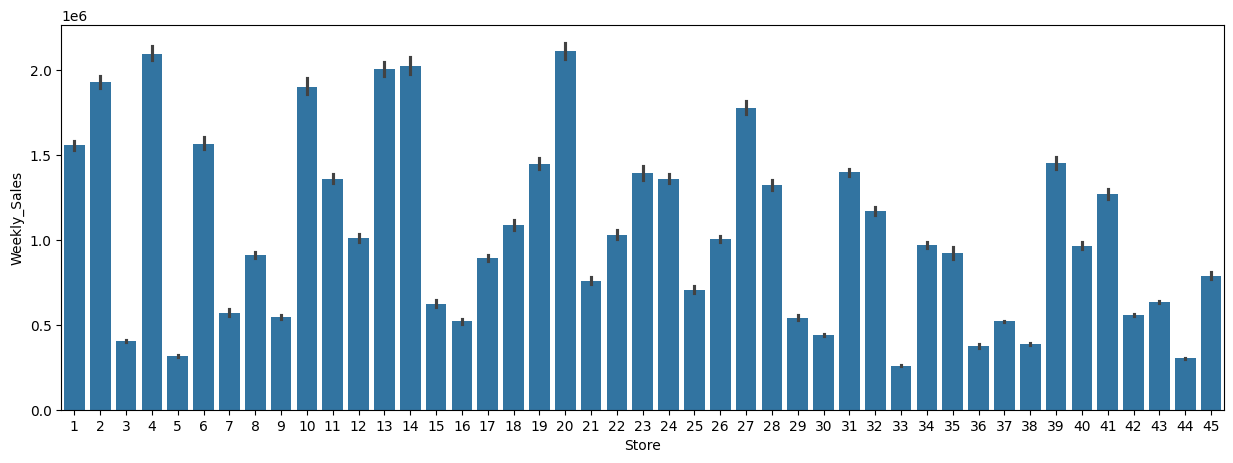

In [ ]:
plt.figure(figsize=(15,5))
sns.barplot(x=hist_data.Store, y=hist_data.Weekly_Sales)

In [ ]:
# from above graph we can see that Store number 20 has Maximum Weekly sales

In [ ]:
# Problem Statement 2:
## Which store has maximum standard deviation i.e, the sales vary a lot. Also, find out the coefficient of mean to standard deviation.

In [ ]:
# maximum Standard deviation
max_std=hist_data.groupby('Store')['Weekly_Sales'].std()
max_std.idxmax()

14

In [ ]:
# here we can see that, store number 14 has maximum standard deviation

In [ ]:
# maximum coefficient of variation
max_cov=((hist_data.groupby('Store')['Weekly_Sales'].std())/(hist_data.groupby('Store')['Weekly_Sales'].mean()))*100
max_cov.idxmax()

35

In [ ]:
walmart_data_std= hist_data.groupby('Store').agg({'Weekly_Sales':['mean','std']})
walmart_data_std.head()

Weekly_Sales               
               mean            std
Store                             
1      1.555264e+06  155980.767761
2      1.925751e+06  237683.694682
3      4.027044e+05   46319.631557
4      2.094713e+06  266201.442297
5      3.180118e+05   37737.965745

In [ ]:
# Problem Statement 3:
## To check which store/s has good quarterly growth rate in Q3'2012

In [ ]:
# Grouping data by year and month
growth= hist_data.copy()
growth['Date']=pd.to_datetime(growth.Date,format='%d-%m-%Y')
growth['Year']=growth['Date'].dt.year
growth['Month']=growth['Date'].dt.month
growth

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3
...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,2012,9
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,2012,10
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,2012,10
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,2012,10


In [ ]:
# Group data with year=2012
growth_rate=growth.groupby('Year')
growth_rate_2012=growth_rate.get_group(2012)
growth_rate_2012.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month
100,1,2012-01-06,1550369.92,0,49.01,3.157,219.714258,7.348,2012,1
101,1,2012-01-13,1459601.17,0,48.53,3.261,219.892526,7.348,2012,1
102,1,2012-01-20,1394393.84,0,54.11,3.268,219.985689,7.348,2012,1
103,1,2012-01-27,1319325.59,0,54.26,3.290,220.078852,7.348,2012,1
104,1,2012-02-03,1636339.65,0,56.55,3.360,220.172015,7.348,2012,2


In [ ]:
hist_data['Date']=pd.to_datetime(hist_data['Date'],format='%d-%m-%Y',errors='coerce')

In [ ]:
growth_rate_2012=hist_data[(hist_data['Date'] >= pd.to_datetime('07-01-2012')) & (hist_data['Date'] <= pd.to_datetime('09-30-2012'))]

In [ ]:
growth_rate_2012=hist_data[(pd.to_datetime(hist_data['Date'])>=pd.to_datetime('07-01-2012')) & (pd.to_datetime(hist_data['Data'])<=pd.to_datetime('09-30-2012'))]

KeyError: 'Data'

In [ ]:
growth_rate_2012= growth_rate_2012.groupby(['Store'])['Weekly_Sales'].sums()
print("Store Number {} has Good Quarterly Growth in Q3'2012 {}",format(growth_rate.idxmax(),growth_rate.max()))

AttributeError: 'SeriesGroupBy' object has no attribute 'sums'

In [ ]:
# Problem Statement 4:
## Some holidays have a negative impact on sales.
## Find out holidays which have higher sales than the mean sales in non-holiday season for all stores together

In [ ]:
# Stores Holiday Sales
stores_holiday_sales=hist_data[hist_data['Holiday_Flag']==1]
# Stores Weekday Sales
stores_nonholiday_sales=hist_data[hist_data['Holiday_Flag']==0]

In [ ]:
# Stores Sales in Super Bowl Day
stores_holiday_sales_superBowl=stores_holiday_sales[(pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('12-02-2010'))|(pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('11-02-2011'))|
                                                    (pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('10-02-2012'))|(pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('08-02-2013'))]

ValueError: time data "26-11-2010" doesn't match format "%m-%d-%Y", at position 2. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
# Stores Sales in Labour Day
stores_holiday_sales_labourday=stores_holiday_sales[(pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('10-09-2010'))|(pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('09-09-2011'))|
                                                    (pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('07-09-2012'))|(pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('06-09-2013'))]

In [ ]:
# Stores Sales in Thanks Giving
stores_holiday_sales_thanksgiving=stores_holiday_sales[(pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('26-11-2010'))|(pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('25-11-2011'))|
                                                    (pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('23-11-2012'))|(pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('29-11-2013'))]

In [ ]:
# Stores Sales in Christmas
stores_holiday_sales_Christmas=stores_holiday_sales[(pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('31-12-2010'))|(pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('30-12-2011'))|
                                                    (pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('28-12-2012'))|(pd.to_datetime(stores_holiday_sales['Date'])==pd.to_datetime('27-12-2013'))]

In [ ]:
stores_nonholiday_sales_mean= stores_nonholiday_sales.groupby(['Date']).agg({"Weekly_Sales":"mean"}).reset_index()

In [ ]:
stores_holiday_sales_sum= stores_holiday_sales.groupby(['Date']).agg({"Weekly_Sales":"sum"}).reset_index()

In [ ]:
for row in stores_holiday_sales_sum.itertuples():
  for row1 in stores_nonholiday_sales_mean.itertuples():
    if row.Weekly_Sales>row1.Weekly_Sales:
      print("On this Date {} Holiday Sales is greater than Non Holiday Sales and the Sales :- {}",format(row.Date,row.Weekly_Sales))
      break;

In [ ]:
# Problem Statement 5:
## Provide a monthly and semester view of sales in units and give insights

In [ ]:
print("Super Bowl Day Sale",stores_holiday_sales_superBowl['Weekly_Sales'].sum())

In [ ]:
print("Labour Day Sale",stores_holiday_sales_labourday['Weekly_Sales'].sum())

In [ ]:
print("Thanksgiving Day Sale",stores_holiday_sales_thanksgiving['Weekly_Sales'].sum())

In [ ]:
print("Christmas Day Sale",stores_holiday_sales_Christmas['Weekly_Sales'].sum())

In [ ]:
# Building prediction models to forecast demand

In [ ]:
x_features_object= hist_data[hist_data['Store']==1][['Store','Date']]
date_obj=hist_data[hist_data['Store']==1][['Date']]
date_obj.index +=1

In [ ]:
x_features_object.Date= date_obj.index
x_features_object.head()

In [ ]:
y_target= hist_data[hist_data['Store']==1]['Weekly_Sales']
y_target.head()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test= train_test_split(x_features_object,y_target,random_state=1)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linreg= LinearRegression()
linreg.fit(x_train,y_train)

In [ ]:
feature_dataset=hist_data[hist_data['Store']==1][['Store','CPI','Unemployment','Fuel_Price']]
feature_dataset.head()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
response_set_cpi= hist_data[hist_data['Store']==1]['CPI'].astype('int64')
response_set_unemployment= hist_data[hist_data['Store']==1]['Unemployment'].astype('int64')

In [ ]:
x_train_cpi,x_test_cpi,y_train_cpi,y_test_cpi= train_test_split(feature_dataset,response_set_cpi,random_state=1)
x_train_unemp,x_test_unemp,y_train_unemp,y_test_unemp= train_test_split(feature_dataset,response_set_unemployment,random_state=1)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logreg= LogisticRegression(max_iter=10000)
logreg.fit(x_train_cpi,y_train_cpi)

In [ ]:
y_pred= logreg.predict(x_test_cpi)

In [ ]:
logreg.fit(x_train_unemp,y_train_unemp)

In [ ]:
y_pred_unemp= logreg.predict(x_test_unemp)

In [ ]:
from sklearn import metrics

In [ ]:
print(metrics.accuracy_score(y_test_cpi,y_pred))

In [ ]:
print(metrics.accuracy_score(y_test_unemp,y_pred_unemp))

In [ ]:
print('cpi actual :',y_test_cpi.values[0:30])

In [ ]:
print('cpi Predicted :',y_pred[0:30])

In [ ]:
print('actual Unemployment :',y_test_unemp.values[0:30])

In [ ]:
print('Predicted Unemployment :',y_pred_unemp[0:30])

In [ ]:
# Change dates into days by creating new variable

In [ ]:
hist_data['Day']=pd.to_datetime(hist_data['Date']).dt.day_name()
hist_data.head()